In [5]:
%pip install networkx matplotlib pandas tqdm gcastle torch pgmpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [6]:
from castle.common import GraphDAG
from castle.datasets import IIDSimulation, DAG
import pandas as pd

# gera um DAG aleatório com pesos
weighted_random_dag = DAG.erdos_renyi(n_nodes=20, n_edges=80, weight_range=(0.5, 2.0), seed=1)

# gera um dataset a partir do DAG
dataset = IIDSimulation(W=weighted_random_dag, n=1000, method='linear', sem_type='gauss')
true_causal_matrix, X = dataset.B, dataset.X

df_X = pd.DataFrame(X, columns=[f'X{i}' for i in range(X.shape[1])])
df_X.head()

2026-04-20 19:05:36,743 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/datasets/simulator.py[line:270] - INFO: Finished synthetic dataset


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
0,-0.937670,10.170980,6.766126,-27.882179,-2.038624,-20.631942,20.810538,-0.095394,-87.518287,1.599662,2.706370,-0.629932,-6.800197,-8.245557,-4.032331,12.317500,20.333780,19.357254,1.105082,-16.366382
1,-3.234290,1.875633,3.962940,-15.807527,-0.750697,-5.866013,9.234515,-1.724166,-46.819745,0.581953,1.567403,-1.986646,-0.923824,-5.254611,-2.525470,11.363472,14.658323,9.343133,1.487900,-13.414938
2,3.034711,-1.710575,-2.419119,8.289166,-0.201739,-3.855897,-0.169822,0.433831,3.534867,1.594526,0.427376,1.200639,2.362779,3.204120,1.117980,9.826761,-6.311053,1.184020,0.131874,-5.921597
3,-4.977831,-4.146613,1.776782,0.706086,-0.221969,14.070934,-6.883102,-2.239469,20.154862,-0.646730,-1.042532,-2.420974,4.348298,-2.248398,-0.323835,-4.794426,1.609109,-4.888999,-0.468346,4.994137
4,-5.475435,-5.231434,-6.694700,25.140980,-0.371327,34.962243,-25.669754,-0.336665,106.864343,-2.355585,-0.602114,1.920582,3.368492,8.841043,3.514577,-32.521323,-31.857247,-24.665898,-1.247737,36.990890


2026-04-20 19:05:37,185 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=1e+16
2026-04-20 19:05:37,853 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.193e-01, loss=2792.860, rho=1.0e+00
2026-04-20 19:05:38,232 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=5.744e-01, loss=10.659, rho=1.0e+00
2026-04-20 19:05:39,003 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.744e-01, loss=13.680, rho=1.0e+01
2026-04-20 19:05:39,500 - /home/luis/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=1.017e-01, 

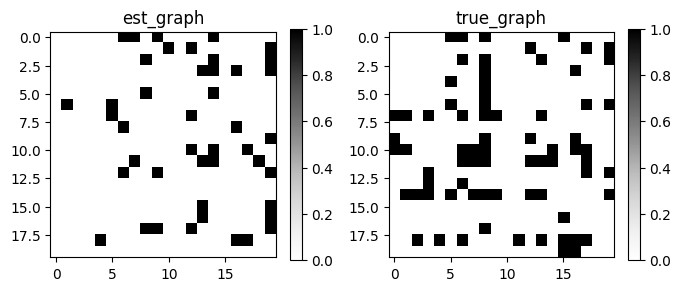

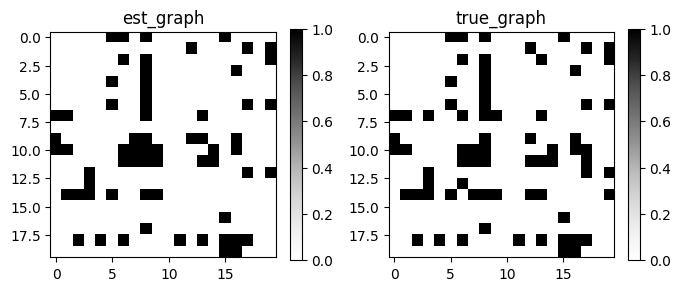

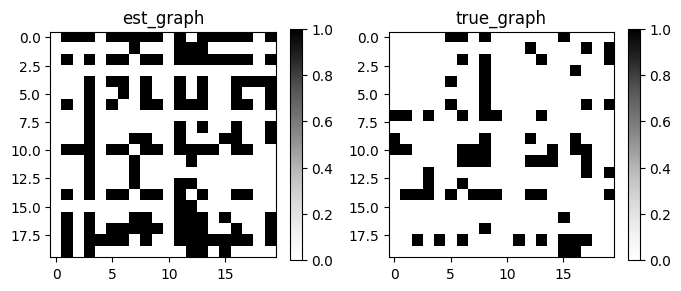

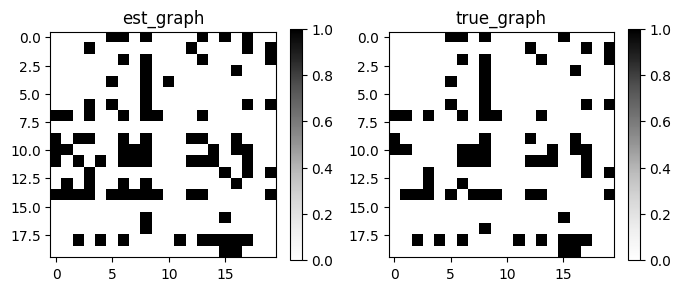

In [7]:
from castle.algorithms import PC, Notears, GES
from castle.metrics import MetricsDAG

pc = PC()
pc.learn(X)

notears = Notears()
notears.learn(X)

ges = GES()
ges.learn(X)

##

## ## ##

GraphDAG(pc.causal_matrix, true_causal_matrix, 'result')
GraphDAG(notears.causal_matrix, true_causal_matrix, 'result')
GraphDAG(ges.causal_matrix, true_causal_matrix, 'result')

from genetic_discovery.main import genetic_discovery

initial_population = [pc.causal_matrix, notears.causal_matrix, ges.causal_matrix]
best_dag = genetic_discovery(X, n_nodes=pc.causal_matrix.shape[0], matrix_initial_pop=initial_population, num_generations=10000, population_size=500, num_parents_mating=5, mutation_rate=0.1)

GraphDAG(best_dag, true_causal_matrix, 'result')

In [8]:
from castle.metrics import MetricsDAG
print("Genetic DAG:")
metrics = MetricsDAG(true_causal_matrix, best_dag)
display(metrics.metrics)

print("PC DAG:")
metrics = MetricsDAG(true_causal_matrix, pc.causal_matrix)
display(metrics.metrics)

print("Notears DAG:")
metrics = MetricsDAG(true_causal_matrix, notears.causal_matrix)
display(metrics.metrics)

print("GES DAG:")
metrics = MetricsDAG(true_causal_matrix, ges.causal_matrix)
display(metrics.metrics)

Genetic DAG:


{'fdr': 0.0,
 'tpr': 0.7849,
 'fpr': 0.0,
 'shd': 20,
 'nnz': 73,
 'precision': np.float64(1.0),
 'recall': np.float64(0.7849),
 'F1': np.float64(0.8795),
 'gscore': np.float64(0.7849)}

PC DAG:


{'fdr': 0.7534,
 'tpr': 0.4091,
 'fpr': 0.3767,
 'shd': 68,
 'nnz': 73,
 'precision': np.float64(0.2466),
 'recall': np.float64(0.4091),
 'F1': np.float64(0.3077),
 'gscore': np.float64(0.0)}

Notears DAG:


{'fdr': 0.1644,
 'tpr': 0.9385,
 'fpr': 0.096,
 'shd': 15,
 'nnz': 73,
 'precision': np.float64(0.8356),
 'recall': np.float64(0.9385),
 'F1': np.float64(0.8841),
 'gscore': np.float64(0.7538)}

GES DAG:


{'fdr': 0.3836,
 'tpr': 0.3041,
 'fpr': 0.6667,
 'shd': 108,
 'nnz': 73,
 'precision': np.float64(0.6164),
 'recall': np.float64(0.3041),
 'F1': np.float64(0.4072),
 'gscore': np.float64(0.1149)}